In [1]:
import numpy as np
from scipy.integrate import odeint,solve_ivp
import matplotlib.pyplot as plt
from scipy import interpolate
from functools import partial
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter
import matplotlib
from numpy import exp
import pandas as pd
%matplotlib inline
from ipywidgets import interact
import math

In [2]:
def get5eqsparams(timescale='day'):
    #parameters are from the paper Mathematical modeling of the hypothalamic-pituitary-adrenal gland (HPA) axis, including hippocampal mechanisms.
    #Andersen M1, Vinther F, Ottesen JT.
    
    a1=1/5 #[1/min]
    a2=1/30 #[1/min]
    a3=1/90 #[1/min]

    #mitosis every ** days according to Nolan et al    
    aP=1/15/(60*24)
    
    # turnover of ** days according to Kataoka et al
    aA=1/15/(60*24)

    
    #We normalize all means to 1, we therefore get
    b1=a1;b2=a2;b3=a3;bA=aA;bP=aP;
    
    res=np.array([a1,a2,a3,aA,aP,b1,b2,b3,bA,bP])
    
    if timescale=='hour':
        res=60*res
    elif timescale=='day':
        res=24*60*res
    else:
        raise ValueError('timescale {} is not defined'.format(timescale))
    
    return res


def class_5(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_/x3_-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


def class_4(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,P_,A_]=y
    dy=np.empty(4)
    #dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[0]= (b2_*P_*u_func(t))/x3_-a2_*x2_ #ACTH#hormone
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#metabolite
    dy[2]= 0   
    dy[3]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


def class_3(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x2_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= u_func(t)-a2_*x2_*x3_ #ACTH#metabolite
    dy[1]= b3_*x2_*A_-a3_*x3_ #Cortisol#hormone
    dy[2]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

def class_2(y,t,timescale='day',u_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x3_,A_]=y
    dy=np.empty(2)
    dy[0]= b3_*u_func(t)*A_-a3_*x3_ #Cortisol#metabolite 
    dy[1]= 0 #Adrenal cells
    return dy

def class_1(y,t,timescale='day',u_func = lambda t:1):
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x3_]=y
    dy=np.empty(1)
    dy[0]= u_func(t)-a3_*x3_ #Cortisol#metabolite 
    #dy[0]= b3_*u_func(t)*A_-a3_*x3_ #Cortisol#metabolite 
    #dy[1]= 0 #Adrenal cells
    return dy

In [7]:
#simulating stress as step function:
def stress_input_short_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

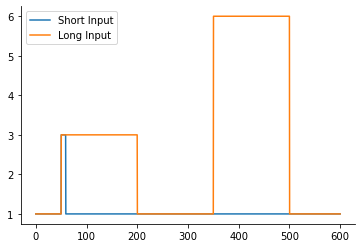

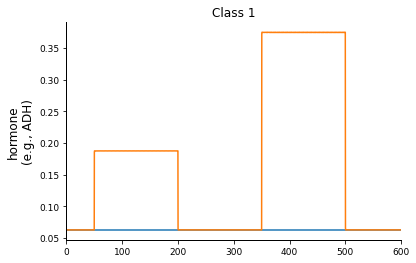

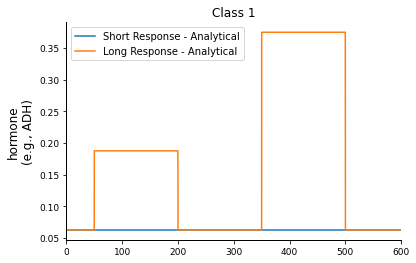

In [8]:
t_recovery = np.linspace(0, 600, 3000)
[a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_] = get5eqsparams("day")
y0 = 1 / a3_

sol_short_1 = solve_ivp(
    fun=lambda t, y: class_1(y, t, timescale='day', u_func=stress_input_short_1),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[y0],
)
sol_long_1 = solve_ivp(
    fun=lambda t, y: class_1(y, t, timescale='day', u_func=stress_input_long_1),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[y0],
)

plt.plot(t_recovery, [stress_input_short_1(t) for t in t_recovery], label='Short Input')
plt.plot(t_recovery, [stress_input_long_1(t) for t in t_recovery], label='Long Input')
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

plt.plot(sol_short_1.t, sol_short_1.y.T)
plt.plot(sol_long_1.t, sol_long_1.y.T)
plt.title("Class 1")
#plt.legend()
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.show()

plt.plot(sol_short_1.t, class_1_sol(sol_short_1.t, [y0], timescale='day', u_func=stress_input_short_1), label="Short Response - Analytical")
plt.plot(sol_long_1.t, class_1_sol(sol_long_1.t, [y0], timescale='day', u_func=stress_input_long_1), label="Long Response - Analytical")
plt.title("Class 1")
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.show()

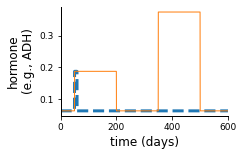

In [9]:
def custom_y(x):
    if x < 50:
        return 1/16
    elif 50 <= x < 59:
        return 3/16
    else:
        return 1/16
    
def long_input(z):
    if 0<z<=50:
        return 1/16
    elif 50<z<=200:
        return 3/16
    elif 200<z<=350:
        return 1/16
    elif 350<z<=500:
        return 6/16
    else:
        return 1/16 
   
# Generate x values from 0 to 100 (or any range you prefer)
x_values = np.linspace(0, 600, 3000)
z_values = np.linspace(0, 600, 3000)

# Calculate corresponding y values using the custom function
y_values = np.array([custom_y(x) for x in x_values])
y_long = np.array([long_input(z) for z in z_values])

plt.figure(figsize=(3,2))

# Plot the curve
plt.plot(x_values, y_values,'--',linewidth='3')
plt.plot(x_values, y_long, linewidth='1' )

# Show the plot


# Add labels and title

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.savefig("class 1 hormone pulse simulation.svg", transparent=True)
plt.show()


In [10]:
#simulating stress as step function:
def stress_input_short_2(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
    # if 50<t<=80:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_2(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

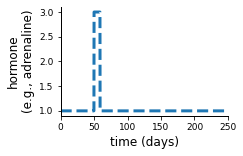

In [11]:
t_recovery = np.linspace(0, 600, 3000)
sol_short_2 = solve_ivp(
    fun=lambda t, y: class_2(y, t, timescale='day', u_func=stress_input_short_2),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[1, 1],
    method='Radau',
    t_eval=t_recovery
)
sol_long_2 = solve_ivp(
    fun=lambda t, y: class_2(y, t, timescale='day', u_func=stress_input_long_2),
    t_span=[t_recovery[0], t_recovery[-1]],
    y0=[1, 1],
)

#plt.plot(t_recovery, [stress_input_short_2(t) for t in t_recovery], label='Short Input')
#plt.plot(t_recovery, [stress_input_long_2(t) for t in t_recovery], label='Long Input')
#plt.legend()
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.show()

#plt.plot(sol_short_2.t, sol_short_2.y[0], label="Short Response - Simulation")
#plt.plot(sol_long_2.t, sol_long_2.y[0], label="Long Response - Simulation")
#plt.title("Class 2")
#plt.legend()
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.show()

plt.figure(figsize=(3,2))
plt.plot(sol_short_2.t, class_2_sol(sol_short_2.t, [1, 1], timescale='day', u_func=stress_input_short_2),'--',linewidth='3')
#plt.plot(sol_long_2.t, class_2_sol(sol_long_2.t, [1, 1], timescale='day', u_func=stress_input_long_2),linewidth='1')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,250)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.ylabel('hormone\n(e.g., adrenaline)',fontsize=12)
plt.savefig("class 2 hormone pulse simulation.svg", transparent=True)
plt.show()

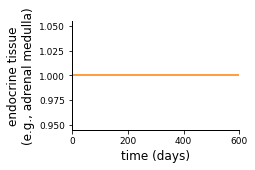

In [12]:
#plotting gland mass dynamics class 2:

x_values = np.linspace(0, 600, 1000)  
y_values = np.ones_like(x_values)  

plt.figure(figsize=(3,2))
plt.plot(x_values, y_values, color=(1, 0.5, 0))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlim(0,600)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.ylabel('endocrine tissue\n(e.g., adrenal medulla)',fontsize=12)
plt.savefig("class 2 gland mass dynamics.svg", transparent=True)
plt.show()



In [13]:
#simulating stress as step function:
def stress_input_short_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_1(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

In [ ]:
#Figure S1:

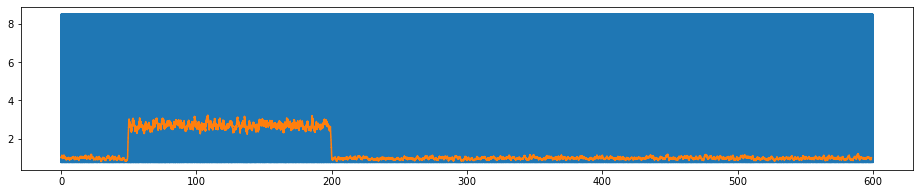

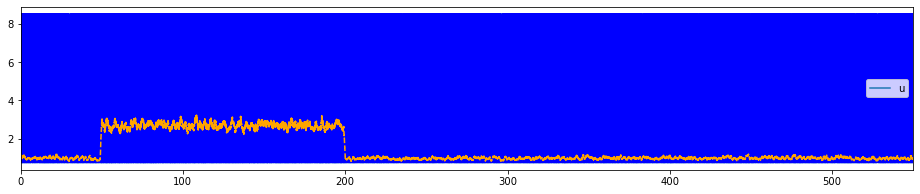

Text(0.5, 1.0, 'class 3 metabolite dynamics')

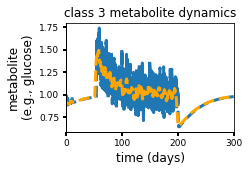

In [16]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

def pulsatile_input(t, freq, dt):
    '''Takes in length of time t (in days)
       and pulse frequency freq (in 1/minutes)
       Returns vector of u with time points every dt days.'''
    numpulses = int(t * 24 * 60 * freq)
    u = np.zeros(int(t / dt))
    starts = (np.random.rand(numpulses) * len(u)).astype(int)
    width = int(dt * 24 * 60 / 0.5) # all pulses about 3 minutes long
    for p in range(numpulses):
        u[starts[p]:starts[p]+width] = 1
    
    return u

DT = 0.001# from your linspace
f0 = 0.01
f1 = 0.1
u1 = pulsatile_input(50, f0, DT)
u2 = pulsatile_input(150, f1, DT)
u3 = pulsatile_input(400, f0, DT)
u_square = np.concatenate((u1, u2, u3))
t_square = np.linspace(0,600,len(u_square))

baseline = int(DT*24*60/0.5) * 24*60*DT  * f0
height = int(DT*24*60/0.5) * 24*60*DT  * f1
u_square = 1 + (u_square-baseline) * 2/(height-baseline)

plt.figure(figsize=(16,3))
plt.plot(t_square, u_square)
plt.plot(t_square[:-999], moving_average(u_square, 1000))


plt.figure(figsize=(16,3))
plt.plot(t_square, u_square)
plt.plot(t_square[:-999], moving_average(u_square, 1000))
plt.xlim(47, 52)

def random_square(t):
    #return u_square[[int(pt / DT)-1 for pt in t]]
    if t/DT -1 > len(u_square):
        return 1
    return u_square[int(t / DT)-1]


#u_fromfunc = random_square(t_square)
#plt.figure(figsize=(16,3))
#plt.plot(t_square, u_fromfunc)
#plt.plot(t_square[:-999], moving_average(u_fromfunc, 1000))

###################################################################
#class 3 metabolite levels- trains 
plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
plt.xlim(0,550)
plt.legend(['u'])
plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = random_square),[1,(1/48),(1/48)],t_square)
plt.plot(t_square,sol_trains_class_3[:,0],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_3[:,0],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('metabolite\n(e.g., glucose)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title("class 3 metabolite dynamics",fontsize=12)
#plt.savefig("class 3 metabolite train simulation.svg", transparent=True)

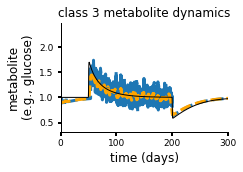

In [24]:
plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = random_square),[1,(1/48),(1/48)],t_square)
plt.plot(t_square,sol_trains_class_3[:,0],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_3[:,0],3000),'--',linewidth='3', color='orange')
plt.plot(t_recovery,sol_slow_class_3[:,0],linewidth='1',color='black')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('metabolite\n(e.g., glucose)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title("class 3 metabolite dynamics",fontsize=12)
plt.savefig("class 3 metabolite train simulation.svg", transparent=True)

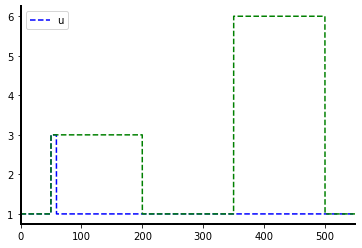

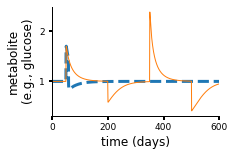

In [25]:
#class 3 metabolite levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_3(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
plt.xlim(0,550)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_short_3),[1,(1/48),(1/48)],t_recovery)
sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_3[:,0],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_3[:,0],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('metabolite\n(e.g., glucose)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.savefig("class 3 metabolite pulse simulation.svg", transparent=True)

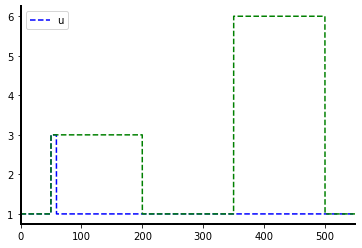

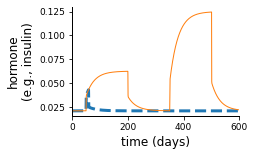

In [21]:
#class 3 hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_3(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
plt.xlim(0,550)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_short_3),[1,(1/48),(1/48)],t_recovery)
sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_3[:,1],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_3[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., insulin)',fontsize=12)
plt.savefig("class 3 hormone pulse simulation.svg", transparent=True)

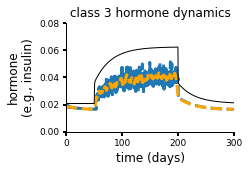

In [28]:
#class 3 hormone levels- trains 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = random_square),[1,(1/48),(1/48)],t_square)
plt.plot(t_square,sol_trains_class_3[:,1],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_3[:,1],3000),'--',linewidth='3', color='orange')
plt.plot(t_recovery,sol_slow_class_3[:,1],linewidth='1',color='black')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.ylim(0,0.08)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., insulin)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 3 hormone dynamics', fontsize=12)
plt.savefig("class 3 hormone train simulation.svg", transparent=True)

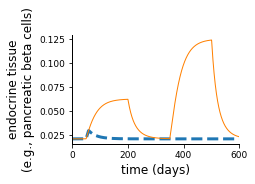

In [29]:
#class 3 gland mass dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_3[:,2],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_3[:,2],linewidth='1',color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('endocrine tissue\n(e.g., pancreatic beta cells)',fontsize=12)
plt.savefig("class 3 gland mass dynamics.svg", transparent=True)

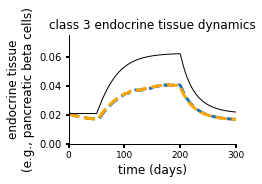

In [31]:
#class 3- gland mass dynamics- trains:
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = random_square),[1,(1/48),(1/48)],t_square)
plt.plot(t_square,sol_trains_class_3[:,2],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_3[:,2],3000),'--',linewidth='3', color='orange')
plt.plot(t_recovery,sol_slow_class_3[:,2],linewidth='1',color='black')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.ylim(0,0.075)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
#plt.yticks([1,2], fontsize=9)
plt.ylabel('endocrine tissue\n(e.g., pancreatic beta cells)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 3 endocrine tissue dynamics',fontsize=12)
plt.savefig("class 3 endocrine tissue train simulation.svg", transparent=True)

In [25]:
#simulating stress as step function:
def stress_input_short_4(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_4(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

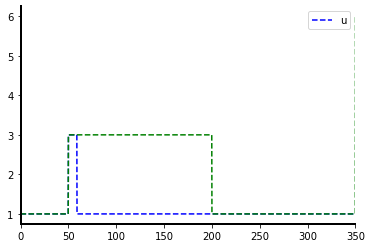

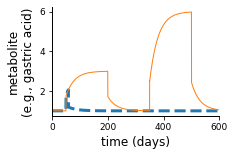

In [26]:
#class 4 metabolite levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_4(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_4(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_short_3),np.ones(4),t_recovery)
sol_slow_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_long_3),np.ones(4),t_recovery)
plt.plot(t_recovery,sol_fast_class_4[:,1],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_4[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('metabolite\n(e.g., gastric acid)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.savefig("class 4 metabolite pulse simulation.svg", transparent=True)

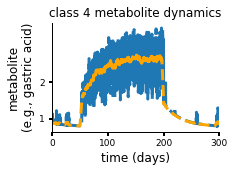

In [27]:
#class 4 metabolite levels- trains 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = random_square),np.ones(4),t_square)
plt.plot(t_square,sol_trains_class_4[:,1],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_4[:,1],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('metabolite\n(e.g., gastric acid)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 4 metabolite dynamics', fontsize=12)
plt.savefig("class 4 metabolite train simulation.svg", transparent=True)

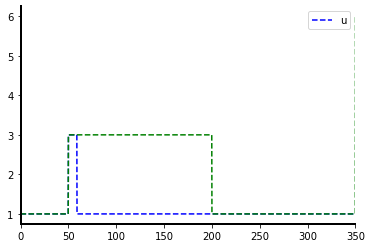

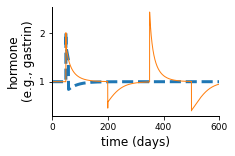

In [28]:
#class 4 hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_4(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_4(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_short_3),np.ones(4),t_recovery)
sol_slow_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = stress_input_long_3),np.ones(4),t_recovery)
plt.plot(t_recovery,sol_fast_class_4[:,0],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_4[:,0],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('hormone\n(e.g., gastrin)',fontsize=12)
plt.savefig("class 4 hormone pulse simulation.svg", transparent=True)

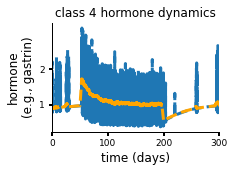

In [78]:
#class 4 hormone levels-trains:
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = random_square),np.ones(4),t_square)
plt.plot(t_square,sol_trains_class_4[:,0],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_4[:,0],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('hormone\n(e.g., gastrin)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 4 hormone dynamics', fontsize=12)
plt.savefig("class 4 hormone train simulation.svg", transparent=True)

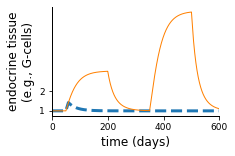

In [30]:
#class 4 gland mass dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_4[:,3],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_4[:,3],linewidth='1',color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('endocrine tissue\n(e.g., G-cells)',fontsize=12)
plt.savefig("class 4 gland dynamics.svg", transparent=True)

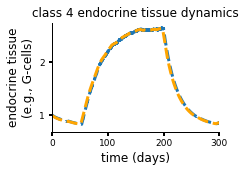

In [80]:
#class 4 gland mass dynamics-trains:
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_4=odeint(lambda y,t: class_4(y,t,timescale='day',u_func = random_square),np.ones(4),t_square)
plt.plot(t_square,sol_trains_class_4[:,3],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_4[:,3],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('endocrine tissue\n(e.g., G-cells)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 4 endocrine tissue dynamics',fontsize=12)
plt.savefig("class 4 endocrine tissue train simulation.svg", transparent=True)

In [32]:
#simulating stress as step function:
def stress_input_short_5(t):
    if 0<t<=50:
        return 1
    if 50<t<=59:
        return 3
    if t>59:
        return 1
    return 1

def stress_input_long_5(t):
    if 0<t<=50:
        return 1
    if 50<t<=200:
        return 3
    if 200<t<=350:
        return 1
    if 350<t<=500:
        return 6
    if t>500:
        return 1 
    return 1

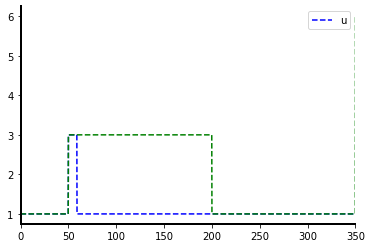

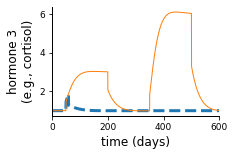

In [33]:
#class 5 end hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_5(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_5(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_short_5),np.ones(5),t_recovery)
sol_slow_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_long_5),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_fast_class_5[:,2],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,2],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('hormone 3\n(e.g., cortisol)',fontsize=12)
plt.savefig("class 5 hormone 3 pulse simulation.svg", transparent=True)

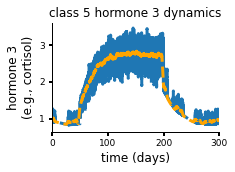

In [86]:
#class 5 end hormone levels- trains: 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = random_square),np.ones(5),t_square)
plt.plot(t_square,sol_trains_class_5[:,2],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_5[:,2],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone 3\n(e.g., cortisol)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 5 hormone 3 dynamics')
plt.savefig("class 5 end hormone train simulation.svg", transparent=True)

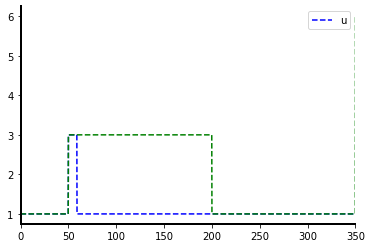

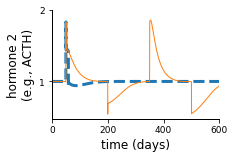

In [35]:
#class 5 middle hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_5(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_5(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_short_5),np.ones(5),t_recovery)
sol_slow_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_long_5),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_fast_class_5[:,1],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2],fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.ylabel('hormone 2\n(e.g., ACTH)',fontsize=12)
plt.savefig("class 5 hormone 3 pulse simulation.svg", transparent=True)

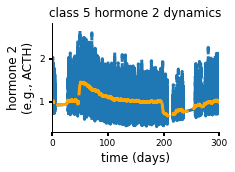

In [87]:
#class 5 middle hormone levels- trains: 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = random_square),np.ones(5),t_square)
plt.plot(t_square,sol_trains_class_5[:,1],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_5[:,1],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone 2\n(e.g., ACTH)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 5 hormone 2 dynamics',fontsize=12)
plt.savefig("class 5 hormone 2 train simulation.svg", transparent=True)

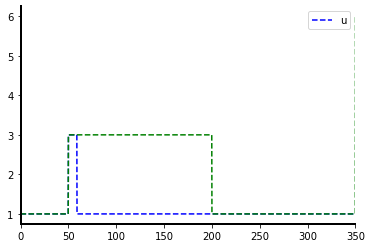

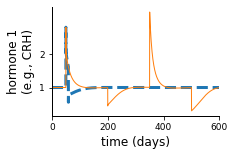

In [37]:
#class 5 "first" hormone levels 
t_recovery=np.linspace(0, 600, 3000)
plt.plot(t_recovery,[stress_input_short_5(x) for x in t_recovery],'--',color='blue')
plt.plot(t_recovery,[stress_input_long_5(x) for x in t_recovery],'--',color='green')
plt.xlim(0,350)
plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_short_5),np.ones(5),t_recovery)
sol_slow_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = stress_input_long_5),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_fast_class_5[:,0],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,0],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
#plt.gca().xaxis.set_major_formatter(FuncFormatter(format_float))
#plt.gca().yaxis.set_major_formatter(FuncFormatter(format_float))
plt.ylabel('hormone 1\n(e.g., CRH)',fontsize=12)
plt.savefig("class 5 hormone 1 pulse simulation.svg", transparent=True)

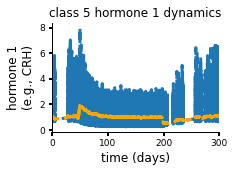

In [90]:
#class 5 first hormone levels- trains: 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = random_square),np.ones(5),t_square)
plt.plot(t_square,sol_trains_class_5[:,0],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_5[:,0],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone 1\n(e.g., CRH)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 5 hormone 1 dynamics',fontsize=12)
plt.savefig("class 5 hormone 1 train simulation.svg", transparent=True)

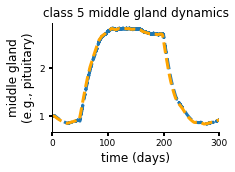

In [93]:
#class 5 middle gland dynamics- trains: 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = random_square),np.ones(5),t_square)
plt.plot(t_square,sol_trains_class_5[:,3],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_5[:,3],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('middle gland\n(e.g., pituitary)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 5 middle gland dynamics',fontsize=12)
plt.savefig("class 5 middle gland train simulation.svg", transparent=True)

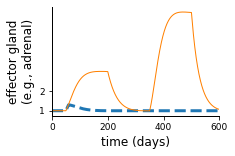

In [41]:
#class 5 end gland dynamics:
plt.figure(figsize=(3,2))
plt.plot(t_recovery,sol_fast_class_5[:,4],'--',linewidth='3')
plt.plot(t_recovery,sol_slow_class_5[:,4],linewidth='1',color=(1, 0.5, 0))
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,600)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
#plt.gca().xaxis.set_major_formatter(FuncFormatter(format_float))
#plt.gca().yaxis.set_major_formatter(FuncFormatter(format_float))
plt.ylabel('effector gland\n(e.g., adrenal)',fontsize=12)
plt.savefig("class 5 effector gland dynamics.svg", transparent=True)

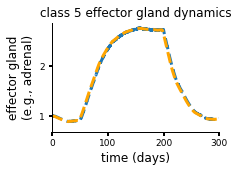

In [138]:
#class 5 end gland dynamics- trains: 
#plt.plot(t_square,[random_square(x) for x in t_square],'--',color='blue')
#plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
#plt.xlim(0,550)
#plt.legend(['u'])
#plt.show()

plt.figure(figsize=(3,2)) # was 3,2
sol_trains_class_5=odeint(lambda y,t: class_5(y,t,timescale='day',u_func = random_square),np.ones(5),t_square)
plt.plot(t_square,sol_trains_class_5[:,4],'--',linewidth='3')
plt.plot(t_square[:-2999],moving_average(sol_trains_class_5[:,4],3000),'--',linewidth='3', color='orange')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (days)',fontsize=12)
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks([1,2], fontsize=9)
plt.ylabel('effector gland\n(e.g., adrenal)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.title('class 5 effector gland dynamics',fontsize=12)
plt.savefig("class 5 effector gland train simulation.svg", transparent=True)

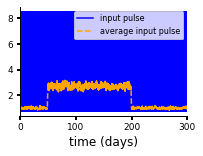

In [140]:
plt.figure(figsize=(3,2))
plt.plot(t_square,[random_square(x) for x in t_square],color='blue')
plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
plt.xlim(0,300)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlabel('time (days)',fontsize=12)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.legend(['input pulse','average input pulse'], fontsize='8',loc='upper right')
plt.savefig("input pulse train simulation.svg", transparent=True)

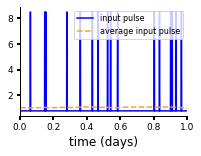

In [142]:
plt.figure(figsize=(3,2))
plt.plot(t_square,[random_square(x) for x in t_square],color='blue')
plt.plot(t_square[:-999],moving_average([random_square(x) for x in t_square],1000),'--',color='orange')
plt.xlim(0,1)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.linewidth'] = 2
plt.tick_params(width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xlabel('time (days)',fontsize=12)
plt.legend(['input pulse','average input pulse'], fontsize='8',loc='upper right')
plt.savefig("input pulse train simulation zoom in.svg", transparent=True)

In [43]:
#Figure S2:

In [44]:
##simulations of class 1_hour timescale for the SI:
def stress_input_short_1_hourtimescale(t):
    if 0<t<=30:
        return 1
    elif 30<t<=40:
        return 3
    elif 40<t<80:
        return 1
    elif 80<t<90:
        return 8
    elif t>90:
        return 1
    return 1

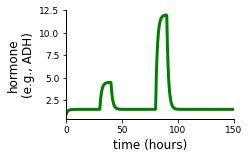

In [45]:
###class 1 short timescale simulations:###
t_recovery=np.linspace(0, 600, 3000)
#plt.plot(t_recovery,[stress_input_short_2_hourtimescale(x) for x in t_recovery],'--',color='blue')
#plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
#plt.xlim(0,550)
#plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_1_hour=odeint(lambda y,t: class_1(y,t,timescale='hour',u_func = stress_input_short_1_hourtimescale),[1],t_recovery)
#sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_1_hour[:,0],color='green',linewidth='3')
#plt.plot(t_recovery,sol_slow_class_3[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (hours)',fontsize=12)
plt.xlim(0,150)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., ADH)',fontsize=12)
plt.savefig("class 1 hormone pulse simulation_hour timescale.svg", transparent=True)

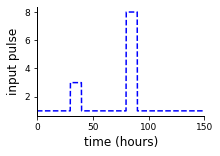

In [46]:
###plotting the input for figure:
#plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
plt.figure(figsize=(3,2))
plt.xlim(0,150)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.plot(t_recovery,[stress_input_short_1_hourtimescale(x) for x in t_recovery],'--',color='blue')
plt.xlabel('time (hours)',fontsize=12)
plt.ylabel('input pulse',fontsize=12)
plt.savefig("input pulse u for short timescale simulations.svg", transparent=True)

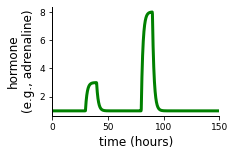

In [47]:
###short timescale simulations class 2- hormone:
t_recovery=np.linspace(0, 600, 3000)
#plt.plot(t_recovery,[stress_input_short_2_hourtimescale(x) for x in t_recovery],'--',color='blue')
#plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
#plt.xlim(0,550)
#plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_2_hour=odeint(lambda y,t: class_2(y,t,timescale='hour',u_func = stress_input_short_1_hourtimescale),[1,1],t_recovery)
#sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_2_hour[:,0],color='green',linewidth='3')
#plt.plot(t_recovery,sol_slow_class_3[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (hours)',fontsize=12)
plt.xlim(0,150)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('hormone\n(e.g., adrenaline)',fontsize=12)
plt.savefig("class 2 hormone pulse simulation_hour timescale.svg", transparent=True)

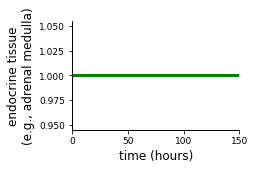

In [48]:
###short timescale simulations class 2- gland:
t_recovery=np.linspace(0, 600, 3000)
#plt.plot(t_recovery,[stress_input_short_2_hourtimescale(x) for x in t_recovery],'--',color='blue')
#plt.plot(t_recovery,[stress_input_long_3(x) for x in t_recovery],'--',color='green')
#plt.xlim(0,550)
#plt.legend(['u'])
plt.show()
plt.figure(figsize=(3,2))
sol_fast_class_2_hour=odeint(lambda y,t: class_2(y,t,timescale='hour',u_func = stress_input_short_1_hourtimescale),[1,1],t_recovery)
#sol_slow_class_3=odeint(lambda y,t: class_3(y,t,timescale='day',u_func = stress_input_long_3),[1,(1/48),(1/48)],t_recovery)
plt.plot(t_recovery,sol_fast_class_2_hour[:,1],color='green',linewidth='3')
#plt.plot(t_recovery,sol_slow_class_3[:,1],linewidth='1')
#plt.legend(['hormone','hormone'])
plt.xlabel('time (hours)',fontsize=12)
plt.xlim(0,150)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylabel('endocrine tissue\n(e.g., adrenal medulla)',fontsize=12)
plt.savefig("class 2 gland pulse simulation_hour timescale.svg", transparent=True)